# Bivariate analysis of categorical variables and the chi-square test

This notebook presents a bivariate analysis of categorical variables, specifically examining the relationship between individuals' regions of origin, birth years and genders. A chi-square test is employed to determine if there is a statistically significant association between these factors over time. 

The aim is to understand how the geographical distribution of the population has changed over time and whether there is a significant over-representation of female astronomers/physicists in certain regions.


In [1]:
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import seaborn as sns

In [2]:
### Librairies déjà installées avec Python
import pprint
import csv
import sys

import time
import datetime
from dateutil import parser
from shutil import copyfile


In [3]:
import warnings
warnings.filterwarnings('ignore')


## Create a dataframe with the data to be analysed

We use in this notebook the data produced in the da2 chapter, i.e. a list of persons with birth year, gender, place of birth, world region of birth

In [4]:
csv_address='da3_data/da3-birthYear-gender-region(3).csv'
df_p = pd.read_csv(csv_address)
df_p.head()

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2,Lombardia,3,3
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8,Toscana,9,9
2,http://www.wikidata.org/entity/Q3771001,Giuseppe Micheli,1874,maschio,Parma,POINT (10.328 44.801472),http://www.wikidata.org/entity/Q2683,1871-1880,7,Emilia-Romagna,8,8
3,http://www.wikidata.org/entity/Q1242,Luigi Einaudi,1874,maschio,Carrù,POINT (7.883333 44.483333),http://www.wikidata.org/entity/Q19372,1871-1880,0,Piemonte,1,1
4,http://www.wikidata.org/entity/Q3839683,Luigi Gasparotto,1873,maschio,Sacile,POINT (12.50274 45.95412),http://www.wikidata.org/entity/Q53190,1871-1880,5,Friuli-Venezia Giulia,6,6


In [5]:
### Inspect the dataframe and 
# notably if there are missing values
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   uriPer              561 non-null    object
 1   labelPer            559 non-null    object
 2   birthYear           561 non-null    int64 
 3   gender              561 non-null    object
 4   labelPlace          561 non-null    object
 5   geometry            561 non-null    object
 6   uriPlace            561 non-null    object
 7   periods             561 non-null    object
 8   index_right         561 non-null    int64 
 9   reg_name            561 non-null    object
 10  reg_istat_code_num  561 non-null    int64 
 11  reg_istat_code      561 non-null    int64 
dtypes: int64(4), object(8)
memory usage: 52.7+ KB


## Distribution of regions of birth

In [6]:
### Group and count
# We observe some dispersion that requires grouping the categories of the variable
df_region = df_p.groupby('reg_name').size()
df_region = pd.DataFrame(df_region.sort_values(ascending = False))
#df_contCode.reset_index(inplace=True)
df_region.columns=['number']
print(df_region)



                              number
reg_name                            
Lombardia                         95
Lazio                             80
Campania                          60
Veneto                            42
Sicilia                           42
Emilia-Romagna                    41
Piemonte                          40
Toscana                           30
Puglia                            29
Liguria                           21
Calabria                          15
Sardegna                          15
Friuli-Venezia Giulia             13
Marche                             9
Umbria                             8
Abruzzo                            7
Molise                             5
Trentino-Alto Adige/Südtirol       5
Basilicata                         4


In [9]:
### Add frequencies to the counts aof a variable's categories

df_region['frequency'] = (100 * df_region['number'] \
                                   / df_region['number'].sum()).round(2)
df_region



,number,frequency
reg_name,,
Lombardia,95,16.93
Lazio,80,14.26
Campania,60,10.70
Veneto,42,7.49
Sicilia,42,7.49
Emilia-Romagna,41,7.31
Piemonte,40,7.13
Toscana,30,5.35
Puglia,29,5.17


In [10]:
### Transform to one row dataframe
ljt = pd.DataFrame(df_region['frequency'].sort_values(ascending=False)).T
ljt

reg_name,Lombardia,Lazio,Campania,Veneto,Sicilia,Emilia-Romagna,Piemonte,Toscana,Puglia,Liguria,Calabria,Sardegna,Friuli-Venezia Giulia,Marche,Umbria,Abruzzo,Molise,Trentino-Alto Adige/Südtirol,Basilicata
frequency,16.93,14.26,10.7,7.49,7.49,7.31,7.13,5.35,5.17,3.74,2.67,2.67,2.32,1.6,1.43,1.25,0.89,0.89,0.71


In [11]:
### Create color palette
colors = plt.cm.tab20(range(10))
print(colors[:2], '\n', colors[-2:])

[[0.12156863 0.46666667 0.70588235 1.        ]
 [0.68235294 0.78039216 0.90980392 1.        ]] 
 [[0.58039216 0.40392157 0.74117647 1.        ]
 [0.77254902 0.69019608 0.83529412 1.        ]]


In [12]:
### Reverse the list
rev_col=colors[::-1]
print(rev_col[:2], '\n', rev_col[-2:])

[[0.77254902 0.69019608 0.83529412 1.        ]
 [0.58039216 0.40392157 0.74117647 1.        ]] 
 [[0.68235294 0.78039216 0.90980392 1.        ]
 [0.12156863 0.46666667 0.70588235 1.        ]]


[]

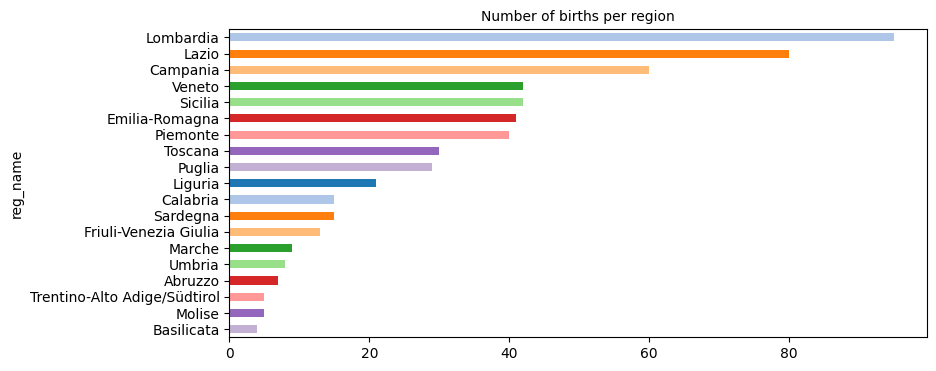

In [13]:
## Distribution of births per region
fig = df_region.number.sort_values().plot(kind='barh', figsize=(9,4), color=rev_col, width=0.5)
fig.set_title('Number of births per region', size=10)
plt.plot()

[]

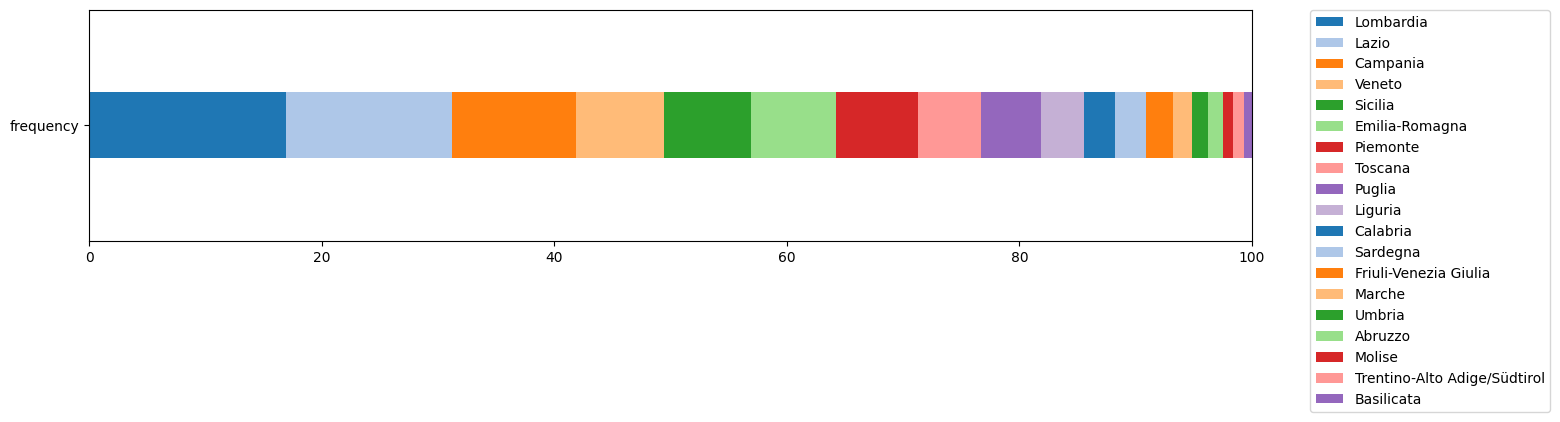

In [14]:
### Pandas plot reference
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html
## Barplots
# https://www.shanelynn.ie/bar-plots-in-python-using-pandas-dataframes/

fig = ljt.plot(kind='barh', stacked=True, figsize=(15,3), color=colors, width=0.2, xlim=[0,100])
fig.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
fig.plot()

### Transform birth years to periods of activity years

In [15]:
### Create imputed activity year
df_p['activityYear'] = df_p.birthYear.apply(lambda x : int(x)+30)

In [16]:
### Create list of 10 years periods

yr = df_p.activityYear

l_10 = list(range(min(yr), max(yr)+11, 10))
print(l_10[:5],l_10[-5:], len(l_10)-1)

[1902, 1912, 1922, 1932, 1942] [1982, 1992, 2002, 2012, 2022] 12


In [17]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# A new column is added containing the period, based on the previous list and the year value

df_p['per_10'] = pd.cut(df_p['activityYear'], l_10, right=False)

### Rewrite the added code to make it more readable
df_p['per_10'] = df_p['per_10'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

# Inspection
df_p.head(3)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code,activityYear,per_10
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2,Lombardia,3,3,1906,1902-1911
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8,Toscana,9,9,1902,1902-1911
2,http://www.wikidata.org/entity/Q3771001,Giuseppe Micheli,1874,maschio,Parma,POINT (10.328 44.801472),http://www.wikidata.org/entity/Q2683,1871-1880,7,Emilia-Romagna,8,8,1904,1902-1911


In [18]:
### Distribution of activities by 10 years periods
activities_per = pd.DataFrame(df_p.groupby(by='per_10').size())
activities_per.columns=['number']
print(activities_per)

           number
per_10           
1902-1911       8
1912-1921      33
1922-1931      30
1932-1941      40
1942-1951      55
1952-1961      97
1962-1971      89
1972-1981      77
1982-1991      66
1992-2001      33
2002-2011      28
2012-2021       5


In [19]:
### Add frequency

activities_per['frequency'] = (100 * activities_per['number'] \
                                   / activities_per['number'].sum()).round(2)
activities_per


,number,frequency
per_10,,
1902-1911,8,1.43
1912-1921,33,5.88
1922-1931,30,5.35
1932-1941,40,7.13
1942-1951,55,9.80
1952-1961,97,17.29
1962-1971,89,15.86
1972-1981,77,13.73
1982-1991,66,11.76


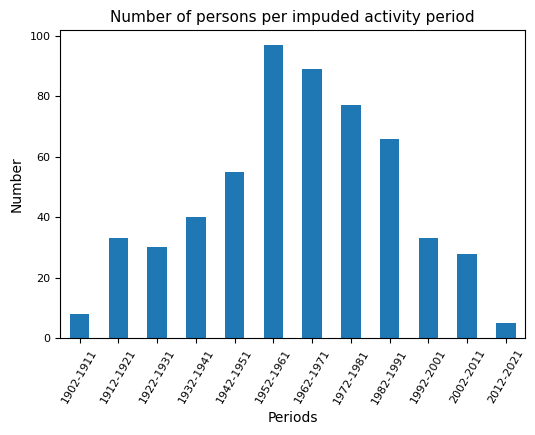

In [20]:
### Distribution by impuded active generations
ax = activities_per.number.plot(kind='bar',rot=60, fontsize=8, figsize=(6,4))
plt.ylabel('Number')
plt.xlabel('Periods')
plt.title('Number of persons per impuded activity period', size=11)
plt.show()

In [21]:
### Transform to a one row dataframe
ljt = pd.DataFrame(activities_per.frequency.sort_index(ascending=True)).T
ljt

per_10,1902-1911,1912-1921,1922-1931,1932-1941,1942-1951,1952-1961,1962-1971,1972-1981,1982-1991,1992-2001,2002-2011,2012-2021
frequency,1.43,5.88,5.35,7.13,9.8,17.29,15.86,13.73,11.76,5.88,4.99,0.89


In [22]:
### Map the intensity of the colours to the frequency

frequencies = activities_per.frequency.sort_index(ascending=True)

# Normalize frequencies to 0-1 range for colormap mapping
norm = mcolors.Normalize(vmin=frequencies.min(), vmax=frequencies.max())

# Create a list of colors based on the 'Blues' colormap
# Higher frequencies get darker blues
colors = [plt.cm.Blues(norm(freq)) for freq in frequencies]

[]

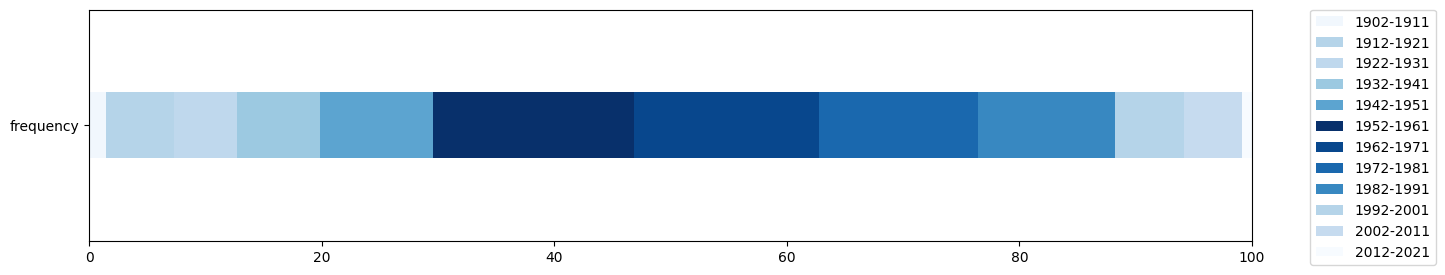

In [23]:
### Frequencies of periods. Total = 100%

fig = ljt.plot(kind='barh', stacked=True, figsize=(15,3), color=colors, width=0.2, xlim=[0,100])
fig.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
fig.plot()

## Bivariate analysis

* A contingency table organises data to show the frequency of two or more categorical variables arranged in rows and columns, revealing possible relationships between them.
* Frequency counts are produced by calculating how often each combination of categories occurs in the dataset.

In [24]:
### Contingency table: 
# count how many individuals exhibit both of these categories for each of the two variables 
per_vs_region=pd.crosstab(df_p.per_10, df_p.reg_name, margins=True)
per_vs_region   

reg_name,Abruzzo,Basilicata,Calabria,Campania,Emilia-Romagna,Friuli-Venezia Giulia,Lazio,Liguria,Lombardia,Marche,Molise,Piemonte,Puglia,Sardegna,Sicilia,Toscana,Trentino-Alto Adige/Südtirol,Umbria,Veneto,All
per_10,,,,,,,,,,,,,,,,,,,,
1902-1911,0,0,0,0,1,1,0,0,2,0,0,2,0,0,0,1,1,0,0,8
1912-1921,0,0,2,2,7,0,4,1,1,1,1,1,2,2,2,2,1,0,4,33
1922-1931,1,0,0,3,1,2,3,1,5,3,0,4,0,1,3,1,0,0,2,30
1932-1941,1,0,1,6,1,2,4,2,8,0,0,1,1,0,4,3,1,0,5,40
1942-1951,2,1,1,2,5,1,10,4,9,1,1,2,3,1,3,3,1,1,4,55
1952-1961,0,1,2,16,4,2,15,3,12,4,1,6,5,5,7,7,1,2,4,97
1962-1971,2,0,6,12,6,2,8,3,18,0,0,7,6,4,3,2,0,3,7,89
1972-1981,1,0,1,5,6,1,11,2,17,0,1,6,4,0,9,4,0,1,8,77
1982-1991,0,1,2,6,7,0,14,4,10,0,1,7,5,1,2,2,0,1,3,66


In [25]:
### If needed, you could restrict to a minimal count and having thus 
# all the periods but with less regions
X_reg_all_period = per_vs_region.loc[:, per_vs_region.iloc[-1] > 500].iloc[:-1, :-1 ]
X_reg_all_period

reg_name
per_10
1902-1911
1912-1921
1922-1931
1932-1941
1942-1951
1952-1961
1962-1971
1972-1981
1982-1991


In [31]:
### But we keep here all the information
X_reg_all_period = per_vs_region.iloc[4:-1, :-1 ]
X_reg_all_period

reg_name,Abruzzo,Basilicata,Calabria,Campania,Emilia-Romagna,Friuli-Venezia Giulia,Lazio,Liguria,Lombardia,Marche,Molise,Piemonte,Puglia,Sardegna,Sicilia,Toscana,Trentino-Alto Adige/Südtirol,Umbria,Veneto
per_10,,,,,,,,,,,,,,,,,,,
1942-1951,2,1,1,2,5,1,10,4,9,1,1,2,3,1,3,3,1,1,4
1952-1961,0,1,2,16,4,2,15,3,12,4,1,6,5,5,7,7,1,2,4
1962-1971,2,0,6,12,6,2,8,3,18,0,0,7,6,4,3,2,0,3,7
1972-1981,1,0,1,5,6,1,11,2,17,0,1,6,4,0,9,4,0,1,8
1982-1991,0,1,2,6,7,0,14,4,10,0,1,7,5,1,2,2,0,1,3
1992-2001,0,0,0,3,2,1,4,1,7,0,0,2,2,1,6,2,0,0,2
2002-2011,0,1,0,4,1,1,7,0,6,0,0,1,1,0,1,2,0,0,3
2012-2021,0,0,0,1,0,0,0,0,0,0,0,1,0,0,2,1,0,0,0


## Chi-square Test of Independence of Categorical Variables

Key distinction:
* Observed Table: Your actual count data. Can contain zeros or small numbers without invalidating the test immediately.
* Expected Table: Calculated values based on row/column totals

$$ E = \frac{\text{row total} \times \text{column total}}{\text{grand total}} $$

* Chi-square :

$$ \chi^2 = \sum_{i=1}^{n} \frac{(O_i - E_i)^2}{E_i} $$

* More about this topic in [Chi-Square Test of Independence: Definition, Formula, and Example](https://www.statology.org/chi-square-test-of-independence/)
* See the whole website: https://www.statology.org/tutorials/


In [32]:
### Calculation of parameters for the chi-square test
statistic, p, dof, expected = stats.chi2_contingency(X_reg_all_period)


In [33]:
### Expected values under independent sampling (H0 hypotheses)

## For the chi-square test the min value in each cell of the expected values should be 5

dfe = pd.DataFrame(expected).round(1)
dfe.index = X_reg_all_period.index
dfe.columns = X_reg_all_period.columns
dfe

reg_name,Abruzzo,Basilicata,Calabria,Campania,Emilia-Romagna,Friuli-Venezia Giulia,Lazio,Liguria,Lombardia,Marche,Molise,Piemonte,Puglia,Sardegna,Sicilia,Toscana,Trentino-Alto Adige/Südtirol,Umbria,Veneto
per_10,,,,,,,,,,,,,,,,,,,
1942-1951,0.6,0.5,1.5,6.0,3.8,1.0,8.4,2.1,9.7,0.6,0.5,3.9,3.2,1.5,4.0,2.8,0.2,1.0,3.8
1952-1961,1.1,0.9,2.6,10.6,6.7,1.7,14.9,3.7,17.0,1.1,0.9,6.9,5.6,2.6,7.1,5.0,0.4,1.7,6.7
1962-1971,1.0,0.8,2.4,9.7,6.1,1.6,13.6,3.4,15.6,1.0,0.8,6.3,5.1,2.4,6.5,4.5,0.4,1.6,6.1
1972-1981,0.9,0.7,2.1,8.4,5.3,1.4,11.8,2.9,13.5,0.9,0.7,5.5,4.4,2.1,5.6,3.9,0.3,1.4,5.3
1982-1991,0.7,0.6,1.8,7.2,4.5,1.2,10.1,2.5,11.6,0.7,0.6,4.7,3.8,1.8,4.8,3.4,0.3,1.2,4.5
1992-2001,0.4,0.3,0.9,3.6,2.3,0.6,5.1,1.2,5.8,0.4,0.3,2.3,1.9,0.9,2.4,1.7,0.1,0.6,2.3
2002-2011,0.3,0.2,0.7,3.0,1.9,0.5,4.3,1.1,4.9,0.3,0.2,2.0,1.6,0.7,2.1,1.4,0.1,0.5,1.9
2012-2021,0.1,0.0,0.1,0.5,0.3,0.1,0.8,0.2,0.9,0.1,0.0,0.4,0.3,0.1,0.4,0.3,0.0,0.1,0.3


In [34]:
## Degrees of freedom and Chi-square

print('Degrees of freedom:', dof, '; Chi-square value:', statistic.round(2))


Degrees of freedom: 126 ; Chi-square value: 111.04


### Probability distribution of Chi-square values in relation to degrees of freedom

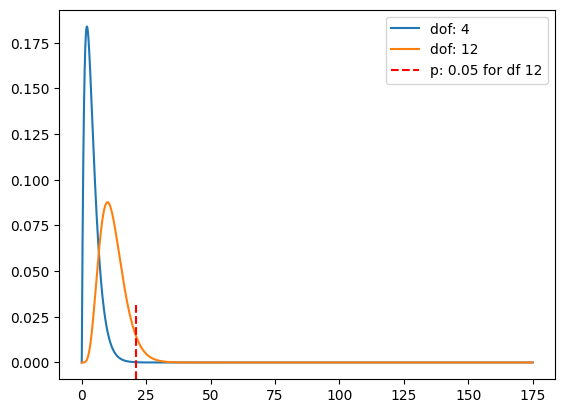

In [35]:
### Documentation ! 
## https://www.statology.org/plot-chi-square-distribution-python/
# x-axis ranges from 0 to 1750 with .001 steps
x = np.arange(0, 175, 0.001)

### plot Chi-square distribution with 4 degrees of freedom
# cf. https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html
plt.plot(x, stats.chi2.pdf(x, df=4), label='dof: 4')
plt.plot(x, stats.chi2.pdf(x, df=12), label='dof: 12')

plt.axvline(x=21.026, ymax=0.2, color='red', linestyle='--', label='p: 0.05 for df 12')

plt.legend()
plt.show()

### Statistical test: rejection of the null hypothesis of independence?

The null hypothesis H0 is that the variables are independent

* e.g. the critical Chi-square value for 12 degrees of freedom, at the 5% level (= 0.05) is 21.026
  * [Chi-square Distribution Table](https://www.statology.org/chi-square-distribution-table/) (Zach Bobbitt)
  * [Chi-squared distribution](https://en.wikipedia.org/wiki/Chi-squared_distribution) (Wikipedia)

* If the chi-square value is above the critical value at a 5% error rate, H0 (the null hypothesis of independence) can be rejected with an error probability under 0.05 (5%). 
* We can then measure the strength of the relationship and its components, including using Cramer’s coefficient

In [36]:
## Degrees of freedom and Chi-square

print('Degrees of freedom:', dof, '; Chi-square value:', statistic.round(2))


Degrees of freedom: 126 ; Chi-square value: 111.04


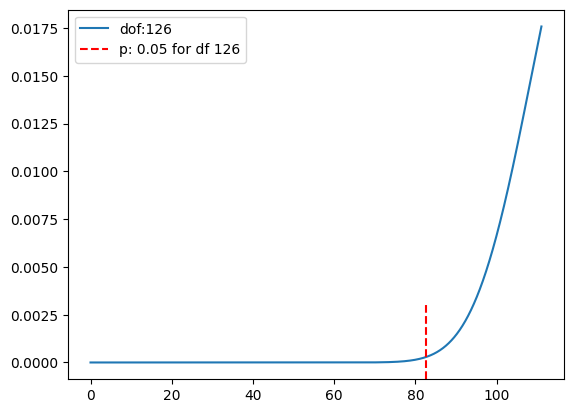

In [37]:
### Applied to our case
x = np.arange(0, statistic, 0.001)

### plot Chi-square distribution with 63 degrees of freedom
plt.plot(x, stats.chi2.pdf(x, df=dof), label='dof:'+ str(dof) )

plt.axvline(x=82.529, ymax=0.2, color='red', linestyle='--', label='p: 0.05 for df ' + str(dof))

plt.legend()
plt.show()

In [38]:
### P-value
print('p-value :', p)

p-value : 0.8263603913628028


### Caveats regarding the expected values table

The Chi-square test relies on a mathematical approximation that assumes the expected distribution is smooth. If the expected count in a cell is too low, the approximation breaks down, even if your actual observed data has high numbers elsewhere.

This is where the "no value < 1" and "max 20% < 5" rules must be checked.

The standard rule of thumb tehrefore states:

* No cell should have an expected frequency less than 1.
* No more than 20% of the cells should have an expected frequency less than 5.

If your table violates these conditions (e.g., many cells < 5 or any cell < 1), the Chi-square approximation may be inaccurate.

### Cramér's V (Cramér's phi coefficient)

* We calculate Cramér's V to measure the strength of the association between the two categorical variables.
* Interpretation of values:
  * 0.0-0.1: neglibigle;
  * 0.1-0.3: weak;
  * 0.3-0.5: moderate;
  * &gt; 0.5: strong

$$ 
V = \sqrt{\frac{\chi^2}{n \times \min(r-1, c-1)}} 
$$

* ${\chi^2}$ = 'statistic' in Python *stats* library
* n = number of individuals
* k = normalization Factor (kk):
  * Formula: k=min⁡(r−1,c−1)k (Minimum)
  * Usage: Used only in the denominator of Cramér's V to normalize the score between 0 and 1.



In [39]:
## Cramer's V with all calculation steps to demonstrate normalization

# 1. Total sample size (n)
n = per_vs_region.iloc[-1, -1]
# print(n)

# 2. Get the dimensions of the table
r, c = X_reg_all_period.shape

# 3. Calculate the correct denominator: min(rows-1, columns-1)
# Note: The returned ‘dof’ is (r-1)*(c-1); this is not directly the divisor for Cramer's rule
k = min(r - 1, c - 1)
# print(k)

# Avoid dividing by zero if the table is 1x1
if k == 0:
    cramers_v = 0
else:
    # 4. Apply the formula
    cramers_v = np.sqrt(statistic / (n * k))

print(f"Cramer's V : {cramers_v.round(5)}")

Cramer's V : 0.16816


In [40]:
### Cramér's V (normalized phi) coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(X_reg_all_period, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.18775420585358596


In [41]:
# 2. Calculate Adjusted Residuals
observed = X_reg_all_period
row_totals = observed.sum(axis=1).values.reshape(-1, 1)
print(row_totals)
col_totals = observed.sum(axis=0).values.reshape(1, -1)
print(col_totals)
n = observed.sum().sum()

[[55]
 [97]
 [89]
 [77]
 [66]
 [33]
 [28]
 [ 5]]
[[ 5  4 12 49 31  8 69 17 79  5  4 32 26 12 33 23  2  8 31]]


In [42]:
# Basic formula
residuals = (round((observed-expected)/np.sqrt(expected),2))
residuals.round(1)

reg_name,Abruzzo,Basilicata,Calabria,Campania,Emilia-Romagna,Friuli-Venezia Giulia,Lazio,Liguria,Lombardia,Marche,Molise,Piemonte,Puglia,Sardegna,Sicilia,Toscana,Trentino-Alto Adige/Südtirol,Umbria,Veneto
per_10,,,,,,,,,,,,,,,,,,,
1942-1951,1.8,0.7,-0.4,-1.6,0.6,0.0,0.5,1.3,-0.2,0.5,0.7,-1.0,-0.1,-0.4,-0.5,0.1,1.5,0.0,0.1
1952-1961,-1.0,0.2,-0.4,1.7,-1.0,0.2,0.0,-0.4,-1.2,2.8,0.2,-0.3,-0.3,1.5,-0.0,0.9,0.9,0.2,-1.0
1962-1971,1.0,-0.9,2.4,0.7,-0.0,0.3,-1.5,-0.2,0.6,-1.0,-0.9,0.3,0.4,1.1,-1.4,-1.2,-0.6,1.1,0.4
1972-1981,0.2,-0.8,-0.7,-1.2,0.3,-0.3,-0.2,-0.5,1.0,-0.9,0.4,0.2,-0.2,-1.4,1.4,0.0,-0.6,-0.3,1.2
1982-1991,-0.9,0.5,0.2,-0.4,1.2,-1.1,1.2,1.0,-0.5,-0.9,0.5,1.1,0.6,-0.6,-1.3,-0.8,-0.5,-0.2,-0.7
1992-2001,-0.6,-0.5,-0.9,-0.3,-0.2,0.5,-0.5,-0.2,0.5,-0.6,-0.5,-0.2,0.1,0.1,2.3,0.2,-0.4,-0.8,-0.2
2002-2011,-0.6,1.5,-0.9,0.5,-0.7,0.7,1.3,-1.0,0.5,-0.6,-0.5,-0.7,-0.5,-0.9,-0.7,0.5,-0.4,-0.7,0.8
2012-2021,-0.2,-0.2,-0.4,0.6,-0.6,-0.3,-0.9,-0.4,-0.9,-0.2,-0.2,1.1,-0.5,-0.4,2.7,1.5,-0.2,-0.3,-0.6


In [43]:
# Formula for Adjusted Residuals
adjusted_resids = (observed - expected) / np.sqrt(expected * (1 - row_totals/n) * (1 - col_totals/n))
adjusted_resids.round(1)

reg_name,Abruzzo,Basilicata,Calabria,Campania,Emilia-Romagna,Friuli-Venezia Giulia,Lazio,Liguria,Lombardia,Marche,Molise,Piemonte,Puglia,Sardegna,Sicilia,Toscana,Trentino-Alto Adige/Südtirol,Umbria,Veneto
per_10,,,,,,,,,,,,,,,,,,,
1942-1951,1.9,0.8,-0.4,-1.8,0.7,0.0,0.6,1.5,-0.2,0.5,0.8,-1.1,-0.1,-0.4,-0.6,0.1,1.6,0.0,0.1
1952-1961,-1.2,0.2,-0.4,2.0,-1.2,0.2,0.0,-0.4,-1.5,3.2,0.2,-0.4,-0.3,1.7,-0.0,1.1,1.0,0.2,-1.2
1962-1971,1.1,-1.0,2.7,0.9,-0.1,0.4,-1.9,-0.2,0.7,-1.1,-1.0,0.3,0.4,1.2,-1.6,-1.4,-0.7,1.3,0.4
1972-1981,0.2,-0.9,-0.8,-1.4,0.3,-0.3,-0.3,-0.6,1.1,-1.0,0.4,0.3,-0.2,-1.6,1.6,0.0,-0.6,-0.3,1.3
1982-1991,-0.9,0.6,0.2,-0.5,1.3,-1.2,1.4,1.1,-0.6,-0.9,0.6,1.2,0.7,-0.6,-1.5,-0.8,-0.6,-0.2,-0.8
1992-2001,-0.6,-0.6,-1.0,-0.3,-0.2,0.6,-0.5,-0.2,0.6,-0.6,-0.6,-0.2,0.1,0.1,2.5,0.3,-0.4,-0.8,-0.2
2002-2011,-0.6,1.6,-0.9,0.6,-0.7,0.7,1.5,-1.1,0.6,-0.6,-0.5,-0.8,-0.5,-0.9,-0.8,0.5,-0.4,-0.7,0.8
2012-2021,-0.2,-0.2,-0.4,0.7,-0.6,-0.3,-1.0,-0.4,-1.0,-0.2,-0.2,1.1,-0.6,-0.4,2.8,1.5,-0.2,-0.3,-0.6


In [44]:
### Using statmodels (sm)

# 1. Create the Table object directly from your data
table = sm.stats.Table(X_reg_all_period)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
adjusted_resids.round(1)

reg_name,Abruzzo,Basilicata,Calabria,Campania,Emilia-Romagna,Friuli-Venezia Giulia,Lazio,Liguria,Lombardia,Marche,Molise,Piemonte,Puglia,Sardegna,Sicilia,Toscana,Trentino-Alto Adige/Südtirol,Umbria,Veneto
per_10,,,,,,,,,,,,,,,,,,,
1942-1951,1.3,0.4,-0.5,-1.7,0.8,-0.1,0.8,1.4,-0.1,0.1,0.4,-1.0,-0.1,-0.5,-0.5,0.2,0.6,-0.1,0.2
1952-1961,-1.0,-0.2,-0.5,2.2,-1.1,0.1,0.2,-0.4,-1.3,2.1,-0.2,-0.3,-0.2,1.5,0.1,1.2,-0.0,0.0,-1.1
1962-1971,0.5,-0.7,2.4,1.0,-0.0,0.2,-1.8,-0.3,0.8,-0.9,-0.7,0.4,0.4,1.0,-1.5,-1.3,-0.5,1.0,0.4
1972-1981,-0.3,-0.6,-0.9,-1.3,0.4,-0.5,-0.2,-0.7,1.2,-0.8,-0.0,0.3,-0.2,-1.3,1.7,0.1,-0.4,-0.5,1.3
1982-1991,-0.6,0.2,0.0,-0.5,1.3,-0.8,1.5,1.0,-0.5,-0.7,0.2,1.2,0.7,-0.7,-1.4,-0.8,-0.3,-0.3,-0.8
1992-2001,-0.1,0.1,-0.6,-0.4,-0.3,0.4,-0.7,-0.4,0.4,-0.2,0.1,-0.3,-0.0,-0.0,2.3,0.2,0.2,-0.3,-0.3
2002-2011,-0.0,1.0,-0.5,0.4,-0.8,0.5,1.2,-0.7,0.3,-0.1,0.2,-0.9,-0.6,-0.5,-0.9,0.4,0.3,-0.2,0.6
2012-2021,0.7,0.9,0.2,-0.3,-0.4,0.5,-1.1,0.0,-1.2,0.6,0.9,0.2,-0.3,0.2,1.3,0.5,1.0,0.5,-0.4


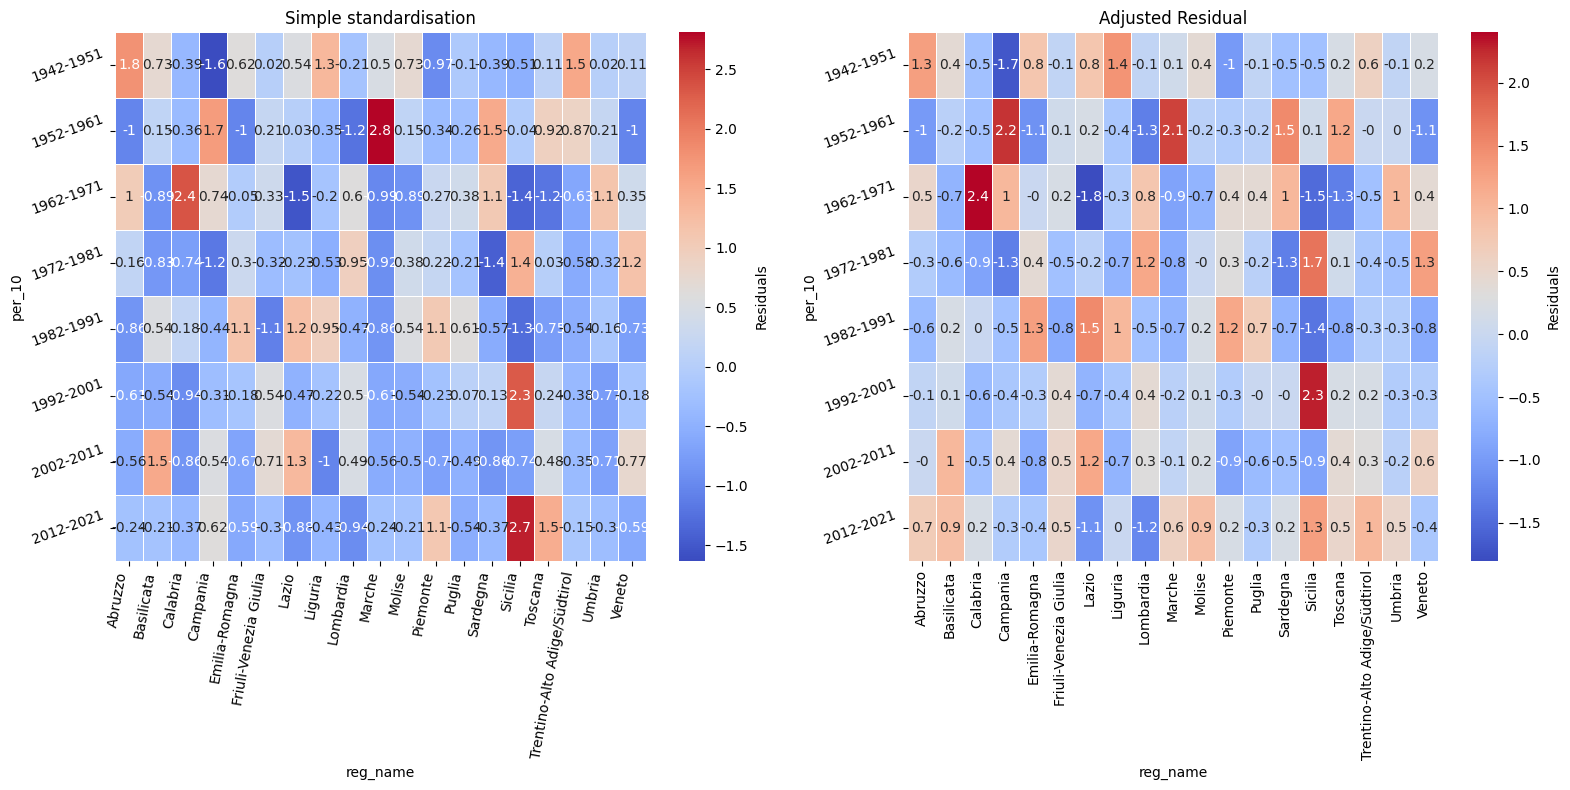

In [45]:
### Compare the two methods of calculation of residuals

# 3. Plot
fig, ax = plt.subplots(1,2,figsize=(16,8))         

# Create heatmap
sns.heatmap(
    residuals, 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax[0],
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=80, ha='right')
ax[0].set_yticklabels(ax[0].get_yticklabels(), rotation=20, va='center')
ax[0].set_title("Simple standardisation", fontsize=12)


# Create heatmap
sns.heatmap(
    adjusted_resids.round(1), 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax[1],
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
#ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right')
ax[1].set_yticklabels(ax[1].get_yticklabels(), rotation=20, va='center')
ax[1].set_title("Adjusted Residual", fontsize=12)

# ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.tight_layout()
plt.show()

Comment : 
* in this case, the differences resulting from standardization are minimal
* in both heatmaps we can easily observe the main differences from the situation of statistical independence and the evolution in time of the number of active astronomres/physicists per region

## Bivariate analysis genders

In [46]:
## filter to only retain statistically significant categories, 
# given the obeserved distribution
df_pg = df_p[df_p['gender'].isin(['femmina', 'maschio'])]

In [50]:
gender_vs_region=pd.crosstab(df_pg.gender, df_pg.reg_name, margins=True)
gender_vs_region

reg_name,Abruzzo,Basilicata,Calabria,Campania,Emilia-Romagna,Friuli-Venezia Giulia,Lazio,Liguria,Lombardia,Marche,Molise,Piemonte,Puglia,Sardegna,Sicilia,Toscana,Trentino-Alto Adige/Südtirol,Umbria,Veneto,All
gender,,,,,,,,,,,,,,,,,,,,
femmina,0,1,2,4,4,0,8,1,11,0,0,8,3,1,7,4,0,1,4,59
maschio,7,3,13,56,37,13,72,20,84,9,5,32,26,14,35,26,5,7,38,502
All,7,4,15,60,41,13,80,21,95,9,5,40,29,15,42,30,5,8,42,561


In [51]:
### All the period but with less regions
# X_reg_all_period = per_vs_region.loc[:, per_vs_region.iloc[-1] > 500].iloc[:-1, :-1 ]
X = gender_vs_region.iloc[:-1, :-1 ]

In [52]:
### Calcul des paramètres pour le test du Chi-2
statistic, p, dof, expected = stats.chi2_contingency(X)


In [53]:
dfe = pd.DataFrame(expected).round(1)
dfe.index = X.index
dfe.columns = X.columns
dfe

reg_name,Abruzzo,Basilicata,Calabria,Campania,Emilia-Romagna,Friuli-Venezia Giulia,Lazio,Liguria,Lombardia,Marche,Molise,Piemonte,Puglia,Sardegna,Sicilia,Toscana,Trentino-Alto Adige/Südtirol,Umbria,Veneto
gender,,,,,,,,,,,,,,,,,,,
femmina,0.7,0.4,1.6,6.3,4.3,1.4,8.4,2.2,10.0,0.9,0.5,4.2,3.0,1.6,4.4,3.2,0.5,0.8,4.4
maschio,6.3,3.6,13.4,53.7,36.7,11.6,71.6,18.8,85.0,8.1,4.5,35.8,26.0,13.4,37.6,26.8,4.5,7.2,37.6


In [54]:
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 13.525344644971034 , dof : 18
p-value : 0.7594678217520111


In [55]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(X, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.15527185431772197


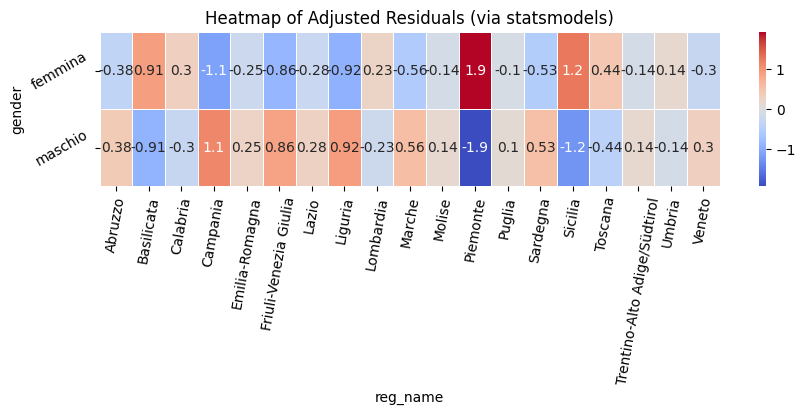

In [56]:
import statsmodels.api as sm

# 1. Create the Table object directly from your data
table = sm.stats.Table(X)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
# 3. Plot
fig, ax = plt.subplots(figsize=(10,2))         
# Sample figsize in inches
ax = sns.heatmap(adjusted_resids, annot=adjusted_resids, cmap="coolwarm", linewidths=.5, ax=ax)
labels = adjusted_resids.index
p = ax.set_yticklabels(labels, rotation=30)
labels_cols = adjusted_resids.columns
p = ax.set_xticklabels(labels_cols, rotation=80)

ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.show()


We can observe that women are more present in some regions. The difference is statistically relevant although weak: Cramer's V = 0.1

## Bivariate analysis genders+generations vs regions

In [57]:
## filter to only retain statistically significant categories, 
# given the obeserved distribution
df_pg = df_p[df_p['gender'].isin(['femmina', 'maschio'])]
df_pg.head(2)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code,activityYear,per_10
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2,Lombardia,3,3,1906,1902-1911
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8,Toscana,9,9,1902,1902-1911


In [58]:
def code_gender_period(gender: str):
    if gender == 'femmina':
        output='f'
    else:
        output='m'
    return output    

In [59]:
df_pg['per_gender']= df_pg.apply(lambda x: x.per_10 +'_'+ code_gender_period(x.gender), axis=1)
df_pg.head(2)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code,activityYear,per_10,per_gender
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2,Lombardia,3,3,1906,1902-1911,1902-1911_m
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8,Toscana,9,9,1902,1902-1911,1902-1911_m


In [62]:
per_gender_vs_region=pd.crosstab(df_pg.per_gender, df_pg.reg_name, margins=True)
per_gender_vs_region

reg_name,Abruzzo,Basilicata,Calabria,Campania,Emilia-Romagna,Friuli-Venezia Giulia,Lazio,Liguria,Lombardia,Marche,Molise,Piemonte,Puglia,Sardegna,Sicilia,Toscana,Trentino-Alto Adige/Südtirol,Umbria,Veneto,All
per_gender,,,,,,,,,,,,,,,,,,,,
1902-1911_m,0,0,0,0,1,1,0,0,2,0,0,2,0,0,0,1,1,0,0,8
1912-1921_m,0,0,2,2,7,0,4,1,1,1,1,1,2,2,2,2,1,0,4,33
1922-1931_m,1,0,0,3,1,2,3,1,5,3,0,4,0,1,3,1,0,0,2,30
1932-1941_m,1,0,1,6,1,2,4,2,8,0,0,1,1,0,4,3,1,0,5,40
1942-1951_m,2,1,1,2,5,1,10,4,9,1,1,2,3,1,3,3,1,1,4,55
1952-1961_f,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,3
1952-1961_m,0,1,2,16,4,2,14,3,12,4,1,5,5,5,7,7,1,2,3,94
1962-1971_f,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,4
1962-1971_m,2,0,6,11,6,2,7,3,18,0,0,6,6,4,3,2,0,3,6,85


In [64]:
per_gender_vs_region=pd.crosstab(df_pg.per_gender, df_pg.reg_name, margins=True)
per_gender_vs_region

reg_name,Abruzzo,Basilicata,Calabria,Campania,Emilia-Romagna,Friuli-Venezia Giulia,Lazio,Liguria,Lombardia,Marche,Molise,Piemonte,Puglia,Sardegna,Sicilia,Toscana,Trentino-Alto Adige/Südtirol,Umbria,Veneto,All
per_gender,,,,,,,,,,,,,,,,,,,,
1902-1911_m,0,0,0,0,1,1,0,0,2,0,0,2,0,0,0,1,1,0,0,8
1912-1921_m,0,0,2,2,7,0,4,1,1,1,1,1,2,2,2,2,1,0,4,33
1922-1931_m,1,0,0,3,1,2,3,1,5,3,0,4,0,1,3,1,0,0,2,30
1932-1941_m,1,0,1,6,1,2,4,2,8,0,0,1,1,0,4,3,1,0,5,40
1942-1951_m,2,1,1,2,5,1,10,4,9,1,1,2,3,1,3,3,1,1,4,55
1952-1961_f,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,3
1952-1961_m,0,1,2,16,4,2,14,3,12,4,1,5,5,5,7,7,1,2,3,94
1962-1971_f,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,4
1962-1971_m,2,0,6,11,6,2,7,3,18,0,0,6,6,4,3,2,0,3,6,85


In [65]:
### All the period but with less regions
# X_reg_all_period = per_vs_region.loc[:, per_vs_region.iloc[-1] > 500].iloc[:-1, :-1 ]
X = per_gender_vs_region.iloc[4:-1, :-1 ]

In [66]:
### Calcul des paramètres pour le test du Chi-2
statistic, p, dof, expected = stats.chi2_contingency(X)


In [67]:
### For significant chi-2 test minimal number in each cell of expected:5
# bias in the results
dfe = pd.DataFrame(expected).round(1)
dfe.index = X.index
dfe.columns = X.columns
dfe

reg_name,Abruzzo,Basilicata,Calabria,Campania,Emilia-Romagna,Friuli-Venezia Giulia,Lazio,Liguria,Lombardia,Marche,Molise,Piemonte,Puglia,Sardegna,Sicilia,Toscana,Trentino-Alto Adige/Südtirol,Umbria,Veneto
per_gender,,,,,,,,,,,,,,,,,,,
1942-1951_m,0.6,0.5,1.5,6.0,3.8,1.0,8.4,2.1,9.7,0.6,0.5,3.9,3.2,1.5,4.0,2.8,0.2,1.0,3.8
1952-1961_f,0.0,0.0,0.1,0.3,0.2,0.1,0.5,0.1,0.5,0.0,0.0,0.2,0.2,0.1,0.2,0.2,0.0,0.1,0.2
1952-1961_m,1.0,0.8,2.5,10.2,6.5,1.7,14.4,3.6,16.5,1.0,0.8,6.7,5.4,2.5,6.9,4.8,0.4,1.7,6.5
1962-1971_f,0.0,0.0,0.1,0.4,0.3,0.1,0.6,0.2,0.7,0.0,0.0,0.3,0.2,0.1,0.3,0.2,0.0,0.1,0.3
1962-1971_m,0.9,0.8,2.3,9.3,5.9,1.5,13.0,3.2,14.9,0.9,0.8,6.0,4.9,2.3,6.2,4.3,0.4,1.5,5.9
1972-1981_f,0.2,0.1,0.4,1.6,1.0,0.3,2.3,0.6,2.6,0.2,0.1,1.1,0.9,0.4,1.1,0.8,0.1,0.3,1.0
1972-1981_m,0.7,0.6,1.7,6.8,4.3,1.1,9.5,2.3,10.9,0.7,0.6,4.4,3.6,1.7,4.5,3.2,0.3,1.1,4.3
1982-1991_f,0.1,0.1,0.3,1.1,0.7,0.2,1.5,0.4,1.8,0.1,0.1,0.7,0.6,0.3,0.7,0.5,0.0,0.2,0.7
1982-1991_m,0.6,0.5,1.5,6.1,3.9,1.0,8.6,2.1,9.8,0.6,0.5,4.0,3.2,1.5,4.1,2.9,0.2,1.0,3.9


If we apply the rule of thumb presented above, we observe that there can be issues with the chi-square test

In [68]:
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 195.298908113749 , dof : 252
p-value : 0.9966798012803029


In [69]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(X, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.17606767643358637


In [70]:
### Standaradized chi-2 contribution
# Basic formula
std_res = (round((X-expected)/np.sqrt(expected),1))
# std_res.head(2)

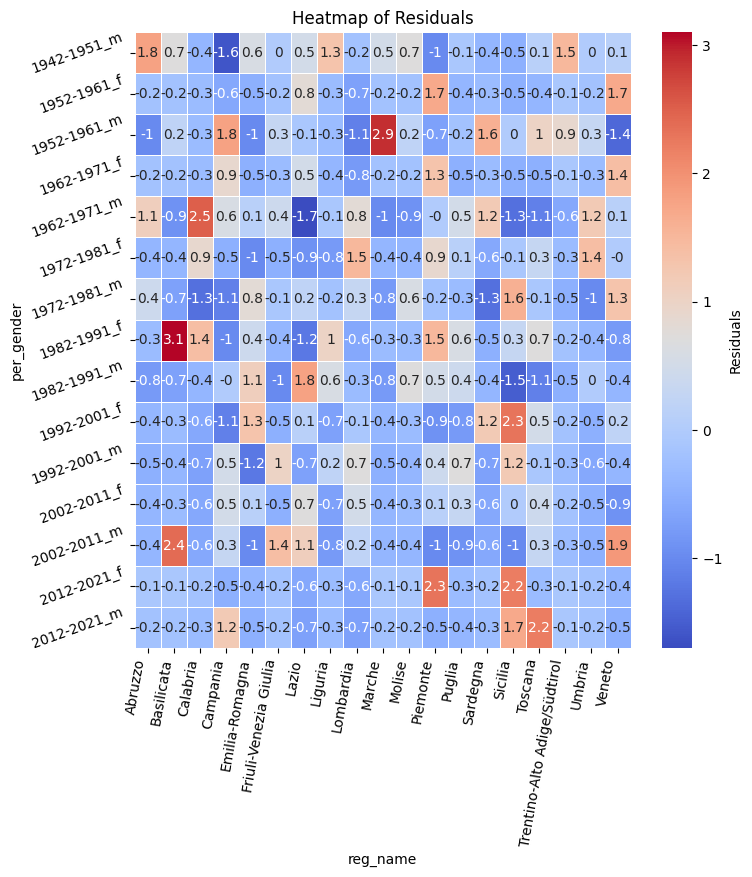

In [71]:
# 3. Plot
fig, ax = plt.subplots(figsize=(8,8))         

# Create heatmap
sns.heatmap(
    std_res, 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax,
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=20, va='center')

ax.set_title("Heatmap of Residuals")
plt.show()

## Possible solution: restrain the table to the more recent values

In [73]:
per_gender_vs_region=pd.crosstab(df_pg.per_gender, df_pg.reg_name, margins=True).iloc[4:, :]
per_gender_vs_region

reg_name,Abruzzo,Basilicata,Calabria,Campania,Emilia-Romagna,Friuli-Venezia Giulia,Lazio,Liguria,Lombardia,Marche,Molise,Piemonte,Puglia,Sardegna,Sicilia,Toscana,Trentino-Alto Adige/Südtirol,Umbria,Veneto,All
per_gender,,,,,,,,,,,,,,,,,,,,
1942-1951_m,2,1,1,2,5,1,10,4,9,1,1,2,3,1,3,3,1,1,4,55
1952-1961_f,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,3
1952-1961_m,0,1,2,16,4,2,14,3,12,4,1,5,5,5,7,7,1,2,3,94
1962-1971_f,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,4
1962-1971_m,2,0,6,11,6,2,7,3,18,0,0,6,6,4,3,2,0,3,6,85
1972-1981_f,0,0,1,1,0,0,1,0,5,0,0,2,1,0,1,1,0,1,1,15
1972-1981_m,1,0,0,4,6,1,10,2,12,0,1,4,3,0,8,3,0,0,7,62
1982-1991_f,0,1,1,0,1,0,0,1,1,0,0,2,1,0,1,1,0,0,0,10
1982-1991_m,0,0,1,6,6,0,14,3,9,0,1,5,4,1,1,1,0,1,3,56


In [74]:
# All the period but with less regions
# X_reg_all_period = per_vs_region.loc[:, per_vs_region.iloc[-1] > 500].iloc[:-1, :-1 ]
X = per_gender_vs_region.iloc[:-1, :-1 ]

In [75]:
### Calcul des paramètres pour le test du Chi-2
statistic, p, dof, expected = stats.chi2_contingency(X)


In [76]:
### For significant chi-2 test minimal number in each cell of expected:5
# bias in the results
dfe = pd.DataFrame(expected).round(1)
dfe.index = X.index
dfe.columns = X.columns
dfe

reg_name,Abruzzo,Basilicata,Calabria,Campania,Emilia-Romagna,Friuli-Venezia Giulia,Lazio,Liguria,Lombardia,Marche,Molise,Piemonte,Puglia,Sardegna,Sicilia,Toscana,Trentino-Alto Adige/Südtirol,Umbria,Veneto
per_gender,,,,,,,,,,,,,,,,,,,
1942-1951_m,0.6,0.5,1.5,6.0,3.8,1.0,8.4,2.1,9.7,0.6,0.5,3.9,3.2,1.5,4.0,2.8,0.2,1.0,3.8
1952-1961_f,0.0,0.0,0.1,0.3,0.2,0.1,0.5,0.1,0.5,0.0,0.0,0.2,0.2,0.1,0.2,0.2,0.0,0.1,0.2
1952-1961_m,1.0,0.8,2.5,10.2,6.5,1.7,14.4,3.6,16.5,1.0,0.8,6.7,5.4,2.5,6.9,4.8,0.4,1.7,6.5
1962-1971_f,0.0,0.0,0.1,0.4,0.3,0.1,0.6,0.2,0.7,0.0,0.0,0.3,0.2,0.1,0.3,0.2,0.0,0.1,0.3
1962-1971_m,0.9,0.8,2.3,9.3,5.9,1.5,13.0,3.2,14.9,0.9,0.8,6.0,4.9,2.3,6.2,4.3,0.4,1.5,5.9
1972-1981_f,0.2,0.1,0.4,1.6,1.0,0.3,2.3,0.6,2.6,0.2,0.1,1.1,0.9,0.4,1.1,0.8,0.1,0.3,1.0
1972-1981_m,0.7,0.6,1.7,6.8,4.3,1.1,9.5,2.3,10.9,0.7,0.6,4.4,3.6,1.7,4.5,3.2,0.3,1.1,4.3
1982-1991_f,0.1,0.1,0.3,1.1,0.7,0.2,1.5,0.4,1.8,0.1,0.1,0.7,0.6,0.3,0.7,0.5,0.0,0.2,0.7
1982-1991_m,0.6,0.5,1.5,6.1,3.9,1.0,8.6,2.1,9.8,0.6,0.5,4.0,3.2,1.5,4.1,2.9,0.2,1.0,3.9


If we apply the rule of thumb presented above, we observe that there can be issues with the chi-square test

In [77]:
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 195.298908113749 , dof : 252
p-value : 0.9966798012803029


In [78]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(X, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.17606767643358637


Comment: not very significant relationship, only some interesting observations on Southern Europe and Central/Southern America

In [79]:
### Standaradized chi-2 contribution
# Basic formula
std_res = (round((X-expected)/np.sqrt(expected),1))
# std_res.head(2)

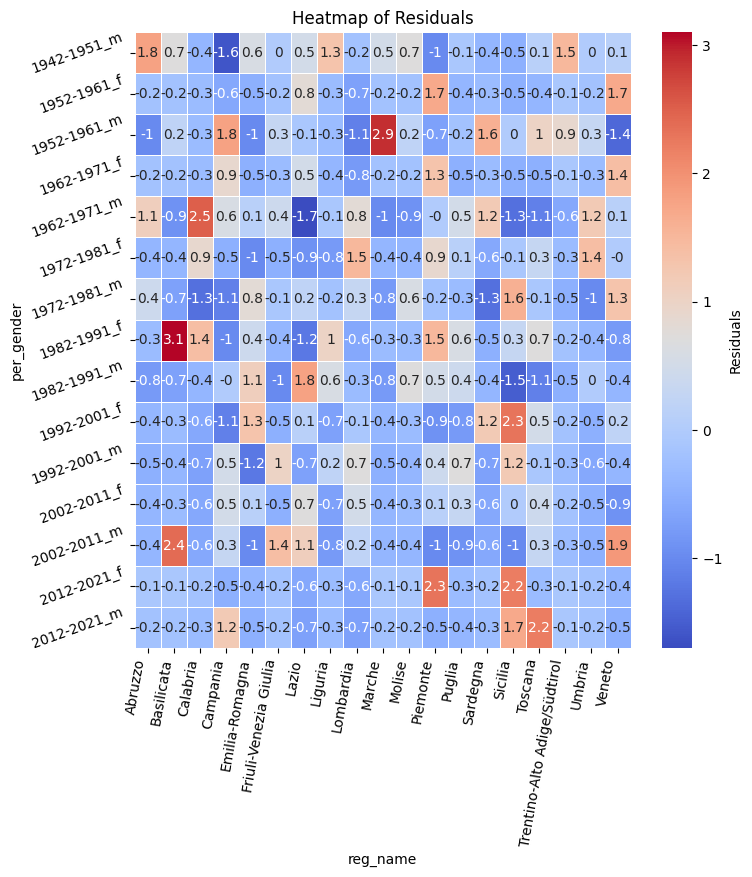

In [80]:
# 3. Plot
fig, ax = plt.subplots(figsize=(8,8))         

# Create heatmap
sns.heatmap(
    std_res, 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax,
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=20, va='center')

ax.set_title("Heatmap of Residuals")
plt.show()

In [81]:
df_pg.head()

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code,activityYear,per_10,per_gender
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2,Lombardia,3,3,1906,1902-1911,1902-1911_m
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8,Toscana,9,9,1902,1902-1911,1902-1911_m
2,http://www.wikidata.org/entity/Q3771001,Giuseppe Micheli,1874,maschio,Parma,POINT (10.328 44.801472),http://www.wikidata.org/entity/Q2683,1871-1880,7,Emilia-Romagna,8,8,1904,1902-1911,1902-1911_m
3,http://www.wikidata.org/entity/Q1242,Luigi Einaudi,1874,maschio,Carrù,POINT (7.883333 44.483333),http://www.wikidata.org/entity/Q19372,1871-1880,0,Piemonte,1,1,1904,1902-1911,1902-1911_m
4,http://www.wikidata.org/entity/Q3839683,Luigi Gasparotto,1873,maschio,Sacile,POINT (12.50274 45.95412),http://www.wikidata.org/entity/Q53190,1871-1880,5,Friuli-Venezia Giulia,6,6,1903,1902-1911,1902-1911_m
